# ECM-402 — AI for Signal Processing | Lab 1B

## Problem 2

This notebook is a standalone, dependency-aware extraction from `ECM402_Lab1B_Solution.ipynb`. Only prerequisite code required for this problem is retained.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.linear_model import Lasso
import pandas as pd

np.random.seed(0)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True

ECG generation/loading — required prerequisite

[Fallback] Could not reach PhysioNet (ModuleNotFoundError: No module named 'wfdb').
Using synthetic ECG instead (fs=360 Hz, ~75 bpm).
Segment length: 3600 samples (10.00 s), source = synthetic


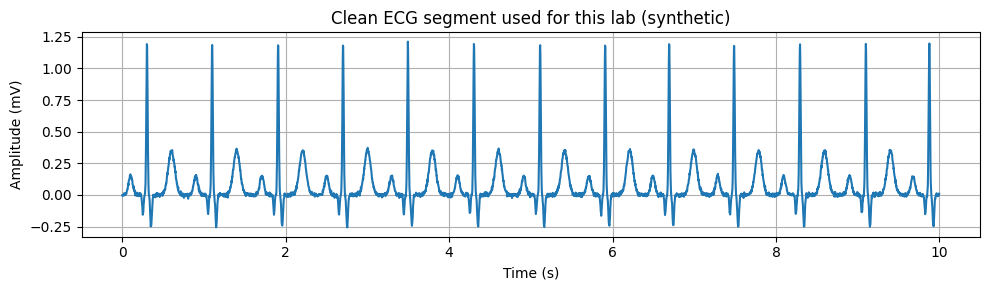

In [13]:

def synthetic_ecg_beat(t, t0, amp_scale=1.0):
    """One PQRST complex, modelled as a sum of Gaussian bumps centred at t0 (the R peak)."""
    def g(mu, sigma, A):
        return A * np.exp(-((t - mu) ** 2) / (2 * sigma ** 2))
    p = g(t0 - 0.20, 0.025, 0.15)
    q = g(t0 - 0.05, 0.008, -0.15)
    r = g(t0, 0.008, 1.20)
    s = g(t0 + 0.05, 0.010, -0.25)
    t_wave = g(t0 + 0.30, 0.040, 0.35)
    return amp_scale * (p + q + r + s + t_wave)


def synthetic_ecg(duration=10.0, fs=360, hr_bpm=75, seed=0):
    """A clean, noise-free-baseline synthetic ECG at a (roughly) fixed heart rate."""
    rng = np.random.default_rng(seed)
    n = int(duration * fs)
    t = np.arange(n) / fs
    rr = 60.0 / hr_bpm
    beat_times = np.arange(0.3, duration, rr)
    beat_times = beat_times + rng.normal(0, 0.01, size=beat_times.shape)  # small HR variability
    s = np.zeros(n)
    for bt in beat_times:
        s += synthetic_ecg_beat(t, bt)
    s += rng.normal(0, 0.008, size=n)  # small measurement noise (part of "clean" signal)
    return s, t, fs, beat_times


def load_ecg(record="100", duration=10.0, seed=0):
    """Try a real MIT-BIH record; fall back to the synthetic generator on any failure."""
    try:
        import wfdb
        rec = wfdb.rdrecord(record, pn_dir="mitdb")
        fs = rec.fs
        n = int(duration * fs)
        s = rec.p_signal[:n, 0].astype(float)
        s = s - np.median(s)
        t = np.arange(n) / fs
        print(f"Loaded REAL MIT-BIH record {record} from PhysioNet (fs={fs} Hz).")
        return s, t, fs, "real"
    except Exception as e:
        s, t, fs, _ = synthetic_ecg(duration=duration, fs=360, hr_bpm=75, seed=seed)
        print(f"[Fallback] Could not reach PhysioNet ({type(e).__name__}: {e}).")
        print("Using synthetic ECG instead (fs=360 Hz, ~75 bpm).")
        return s, t, fs, "synthetic"


s_clean, t, fs, source = load_ecg("100", duration=10.0, seed=0)
print(f"Segment length: {len(s_clean)} samples ({len(s_clean)/fs:.2f} s), source = {source}")

plt.figure(figsize=(10, 3))
plt.plot(t, s_clean)
plt.xlabel("Time (s)"); plt.ylabel("Amplitude (mV)")
plt.title(f"Clean ECG segment used for this lab ({source})")
plt.tight_layout(); plt.show()

Baseline wander and corrupted ECG

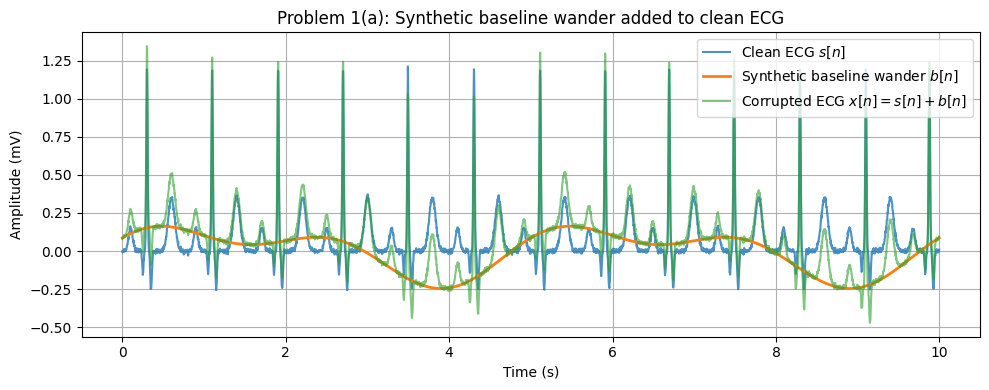

In [14]:

A1, A2 = 0.15, 0.10
f1, f2 = 0.2, 0.4
phi1, phi2 = 0.0, np.pi / 3

b_true = A1 * np.sin(2 * np.pi * f1 * t + phi1) + A2 * np.sin(2 * np.pi * f2 * t + phi2)
x = s_clean + b_true

plt.figure(figsize=(10, 4))
plt.plot(t, s_clean, label="Clean ECG $s[n]$", alpha=0.8)
plt.plot(t, b_true, label="Synthetic baseline wander $b[n]$", linewidth=2)
plt.plot(t, x, label="Corrupted ECG $x[n] = s[n]+b[n]$", alpha=0.6)
plt.xlabel("Time (s)"); plt.ylabel("Amplitude (mV)")
plt.legend(loc="upper right"); plt.title("Problem 1(a): Synthetic baseline wander added to clean ECG")
plt.tight_layout(); plt.show()


TP-segment anchor extraction

Detected 13 R-peaks -> 465 anchor (TP-segment) points.


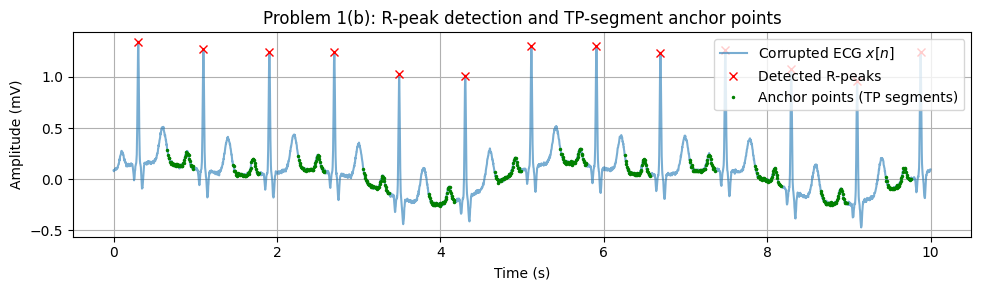

In [15]:
def detect_r_peaks(sig, fs):
    min_distance = int(0.4 * fs)  # refractory period: caps HR at 150 bpm
    height = np.percentile(sig, 85)
    peaks, _ = find_peaks(sig, height=height, distance=min_distance)
    return peaks


def extract_anchor_points(sig, t, r_peaks, frac_start=0.45, frac_end=0.85, subsample=3):
    """Dense, noisy TP-segment samples used as regression targets for the baseline."""
    anchors_t, anchors_y = [], []
    for i in range(len(r_peaks) - 1):
        rr_samples = r_peaks[i + 1] - r_peaks[i]
        start = r_peaks[i] + int(frac_start * rr_samples)
        end = r_peaks[i] + int(frac_end * rr_samples)
        idx = np.arange(start, end, subsample)
        idx = idx[(idx >= 0) & (idx < len(sig))]
        anchors_t.extend(t[idx])
        anchors_y.extend(sig[idx])
    return np.array(anchors_t), np.array(anchors_y)


r_peaks = detect_r_peaks(x, fs)
t_anchor, y_anchor = extract_anchor_points(x, t, r_peaks)
print(f"Detected {len(r_peaks)} R-peaks -> {len(t_anchor)} anchor (TP-segment) points.")

plt.figure(figsize=(10, 3))
plt.plot(t, x, label="Corrupted ECG $x[n]$", alpha=0.6)
plt.plot(t[r_peaks], x[r_peaks], "rx", label="Detected R-peaks")
plt.plot(t_anchor, y_anchor, ".", color="green", markersize=3, label="Anchor points (TP segments)")
plt.legend(loc="upper right"); plt.xlabel("Time (s)"); plt.ylabel("Amplitude (mV)")
plt.title("Problem 1(b): R-peak detection and TP-segment anchor points")
plt.tight_layout(); plt.show()

Evaluation utilities

In [16]:
def mse(a, b):
    return np.mean((a - b) ** 2)


def snr_db(signal, error):
    return 10 * np.log10(np.sum(signal ** 2) / np.sum(error ** 2))


def evaluate(b_true, b_hat, s_true, s_hat):
    return {
        "MSE(b, b_hat)": mse(b_true, b_hat),
        "BSNR (dB)": snr_db(b_true, b_true - b_hat),
        "Output SNR (dB)": snr_db(s_true, s_true - s_hat),
    }

Fit polynomial models

In [17]:
def normalize_time(t_query, t_min, t_max):
    return 2 * (t_query - t_min) / (t_max - t_min) - 1


def vandermonde(t_norm, degree):
    return np.vstack([t_norm ** k for k in range(degree + 1)]).T


def fit_polynomial(t_anchor_norm, y_anchor, degree):
    Phi = vandermonde(t_anchor_norm, degree)
    w = np.linalg.solve(Phi.T @ Phi, Phi.T @ y_anchor)
    return w


def predict_polynomial(t_query_norm, w):
    degree = len(w) - 1
    Phi = vandermonde(t_query_norm, degree)
    return Phi @ w


t_min, t_max = t.min(), t.max()
t_anchor_n = normalize_time(t_anchor, t_min, t_max)
t_full_n = normalize_time(t, t_min, t_max)

degrees = [1, 3, 5, 9, 15, 25]
poly_results = {}
for p in degrees:
    Phi_p = vandermonde(t_anchor_n, p)
    cond_p = np.linalg.cond(Phi_p.T @ Phi_p)
    w = fit_polynomial(t_anchor_n, y_anchor, p)
    b_hat = predict_polynomial(t_full_n, w)
    s_hat = x - b_hat
    poly_results[p] = {"w": w, "b_hat": b_hat, "s_hat": s_hat, "cond": cond_p,
                        "metrics": evaluate(b_true, b_hat, s_clean, s_hat)}
    print(f"degree={p:2d}  cond(Phi^T Phi)={cond_p:.3e}  "
          f"MSE(b,b_hat)={poly_results[p]['metrics']['MSE(b, b_hat)']:.5f}  "
          f"Output SNR={poly_results[p]['metrics']['Output SNR (dB)']:.2f} dB")

degree= 1  cond(Phi^T Phi)=3.298e+00  MSE(b,b_hat)=0.01521  Output SNR=4.21 dB
degree= 3  cond(Phi^T Phi)=8.964e+01  MSE(b,b_hat)=0.01390  Output SNR=4.60 dB
degree= 5  cond(Phi^T Phi)=3.380e+03  MSE(b,b_hat)=0.01049  Output SNR=5.82 dB
degree= 9  cond(Phi^T Phi)=5.760e+06  MSE(b,b_hat)=0.13121  Output SNR=-5.15 dB
degree=15  cond(Phi^T Phi)=4.337e+11  MSE(b,b_hat)=1.43031  Output SNR=-15.53 dB
degree=25  cond(Phi^T Phi)=4.412e+17  MSE(b,b_hat)=130.62260  Output SNR=-35.13 dB


Problem 2(b): Corrected ECG comparison

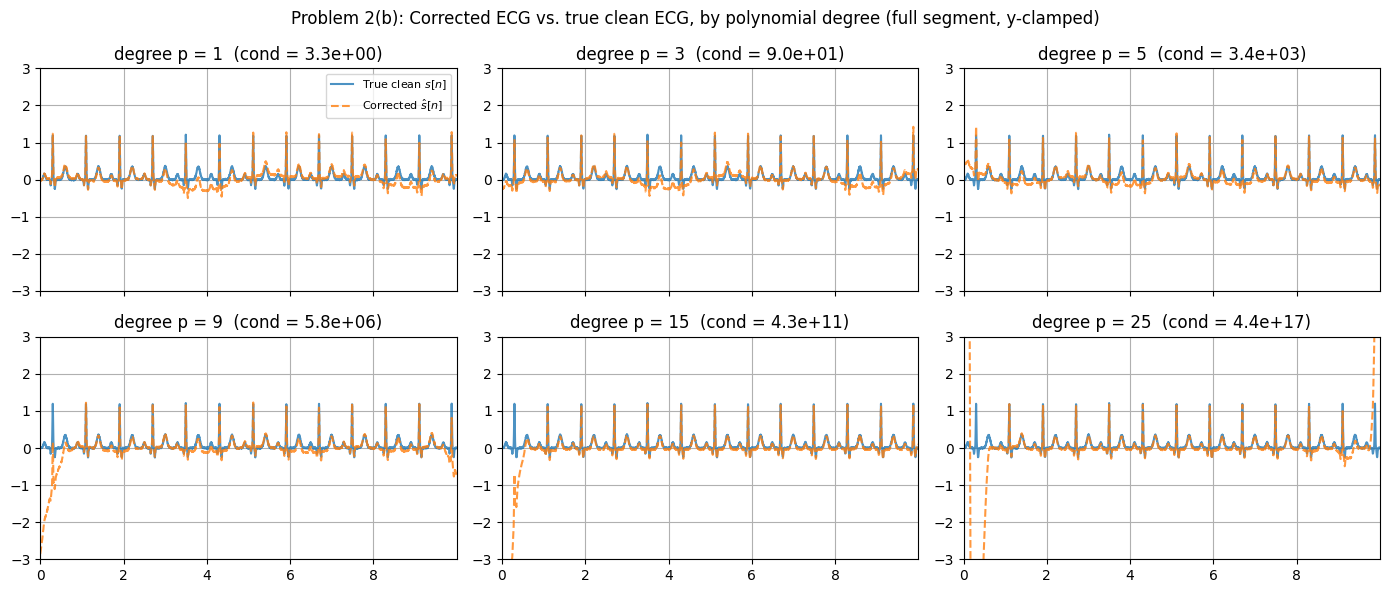

In [18]:

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for ax, p in zip(axes.ravel(), degrees):
    ax.plot(t, s_clean, label="True clean $s[n]$", alpha=0.8)
    ax.plot(t, poly_results[p]["s_hat"], label="Corrected $\\hat s[n]$", alpha=0.8, linestyle="--")
    ax.set_title(f"degree p = {p}  (cond = {poly_results[p]['cond']:.1e})")
    ax.set_xlim(t.min(), t.max())
    ax.set_ylim(-3, 3)  # clamp y-axis: high degrees blow up far outside this range near the edges
fig.suptitle("Problem 2(b): Corrected ECG vs. true clean ECG, by polynomial degree (full segment, y-clamped)")
axes[0, 0].legend(loc="upper right", fontsize=8)
fig.tight_layout(); plt.show()


Problem 2(c): Bias–variance trade-off

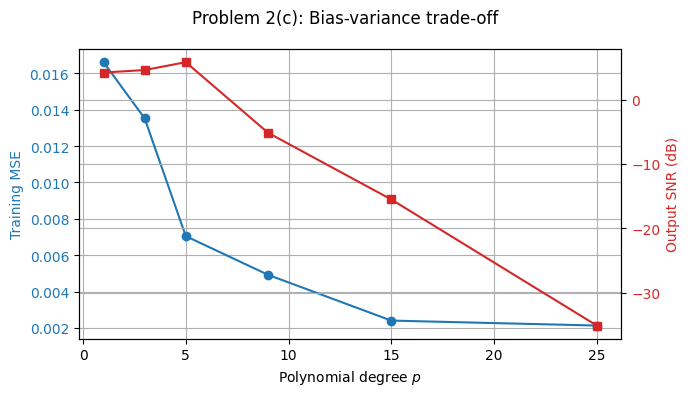

In [19]:
train_mse, eval_snr = [], []
for p in degrees:
    w = poly_results[p]["w"]
    y_hat_anchor = predict_polynomial(t_anchor_n, w)
    train_mse.append(mse(y_anchor, y_hat_anchor))
    eval_snr.append(poly_results[p]["metrics"]["Output SNR (dB)"])

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(degrees, train_mse, "o-", color="tab:blue", label="Training MSE (on anchors)")
ax1.set_xlabel("Polynomial degree $p$"); ax1.set_ylabel("Training MSE", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2 = ax1.twinx()
ax2.plot(degrees, eval_snr, "s-", color="tab:red", label="Output SNR (evaluation)")
ax2.set_ylabel("Output SNR (dB)", color="tab:red"); ax2.tick_params(axis="y", labelcolor="tab:red")
fig.suptitle("Problem 2(c): Bias-variance trade-off")
fig.tight_layout(); plt.show()

Problem 2(d): Ordered train/validation model selection

Validation MSE per degree:
  degree= 1: val MSE = 0.02321  <-- best
  degree= 3: val MSE = 0.06088
  degree= 5: val MSE = 5.34007
  degree= 9: val MSE = 111855.84141
  degree=15: val MSE = 1304090178.39690
  degree=25: val MSE = 1226170336748.17432

Selected p* = 1


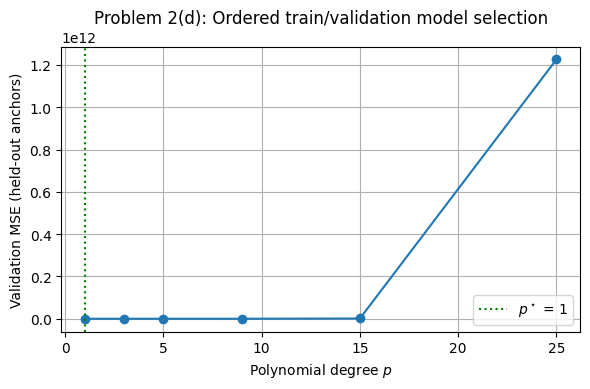

In [20]:


split_idx = int(0.7 * len(t_anchor_n))
order = np.argsort(t_anchor_n)
train_idx, val_idx = order[:split_idx], order[split_idx:]

val_mse_curve = []
for p in degrees:
    w = fit_polynomial(t_anchor_n[train_idx], y_anchor[train_idx], p)
    y_val_hat = predict_polynomial(t_anchor_n[val_idx], w)
    val_mse_curve.append(mse(y_anchor[val_idx], y_val_hat))

p_star = degrees[int(np.argmin(val_mse_curve))]
print("Validation MSE per degree:")
for p, v in zip(degrees, val_mse_curve):
    marker = "  <-- best" if p == p_star else ""
    print(f"  degree={p:2d}: val MSE = {v:.5f}{marker}")
print(f"\nSelected p* = {p_star}")

plt.figure(figsize=(6, 4))
plt.plot(degrees, val_mse_curve, "o-")
plt.axvline(p_star, color="green", linestyle=":", label=f"$p^\\star$ = {p_star}")
plt.xlabel("Polynomial degree $p$"); plt.ylabel("Validation MSE (held-out anchors)")
plt.title("Problem 2(d): Ordered train/validation model selection")
plt.legend(); plt.tight_layout(); plt.show()
